# Proyecto: Análisis y Predicción de Calidad del Vino con Redes Neuronales
### Módulo: Procesamiento Matemático para Ciencia de Datos
### Dataset: VinoMaster

---
## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print('Librerías importadas correctamente.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy:  {np.__version__}')

Librerías importadas correctamente.
Pandas: 2.2.2
NumPy:  1.26.4


---
## 2. Carga y Análisis Inicial de los Datos

In [2]:
# Cargar el dataset
df = pd.read_csv('datos_VinoMaster.csv')

# Limpiar nombres de columnas (elimina saltos de línea y espacios extra)
df.columns = df.columns.str.replace('\n', ' ').str.strip()

print('=== Primeras filas del dataset ===')
print(df.head())
print()
print('=== Descripción estadística básica ===')
print(df.describe())

=== Primeras filas del dataset ===
       id   Type  fixed acidity  volatile acidity  citric  acid  \
0  id0001    red            7.8              0.76          0.04   
1  id0002  white            7.4              0.14          0.30   
2  id0003  white            6.6              0.18          0.28   
3  id0004  white            6.6              0.22          0.37   
4  id0005  white            6.5              0.18          0.26   

   residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  \
0             2.3      0.092                 15.0                  54.0   
1             1.3      0.033                 25.0                  91.0   
2             1.7      0.041                 53.0                 161.0   
3            15.4      0.035                 62.0                 153.0   
4             1.4      0.041                 40.0                 141.0   

   density    pH  sulphates  alcohol  quality  
0  0.99700  3.26       0.65      9.8        5  
1  0.99268  3.5

In [3]:
# Información general del dataset
print('=== Información del DataFrame ===')
print(df.info())
print()
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print()
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
print()
print('=== Distribución de tipos de vino ===')
print(df['Type'].value_counts())

=== Información del DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    6497 non-null   object 
 1   Type                  6497 non-null   object 
 2   fixed acidity         6497 non-null   float64
 3   volatile acidity      6497 non-null   float64
 4   citric  acid          6497 non-null   float64
 5   residual sugar        6497 non-null   float64
 6   chlorides             6497 non-null   float64
 7   free sulfur dioxide   6497 non-null   float64
 8   total sulfur dioxide  6497 non-null   float64
 9   density               6497 non-null   float64
 10  pH                    6497 non-null   float64
 11  sulphates             6497 non-null   float64
 12  alcohol               6497 non-null   float64
 13  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(2)
me

---
## 3. Visualizaciones del Análisis Exploratorio

C:\Users\Aleja\AppData\Local\Temp\ipykernel_36056\390207802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


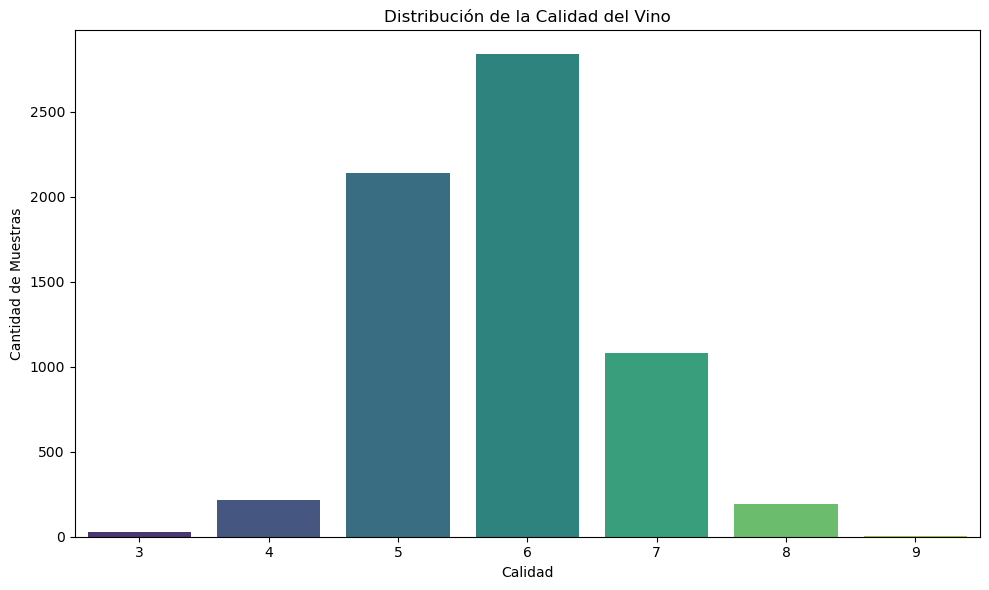

In [4]:
# Distribución de la variable objetivo: quality
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribución de la Calidad del Vino')
plt.xlabel('Calidad')
plt.ylabel('Cantidad de Muestras')
plt.tight_layout()
plt.savefig('grafica_distribucion_calidad.png', dpi=150)
plt.show()

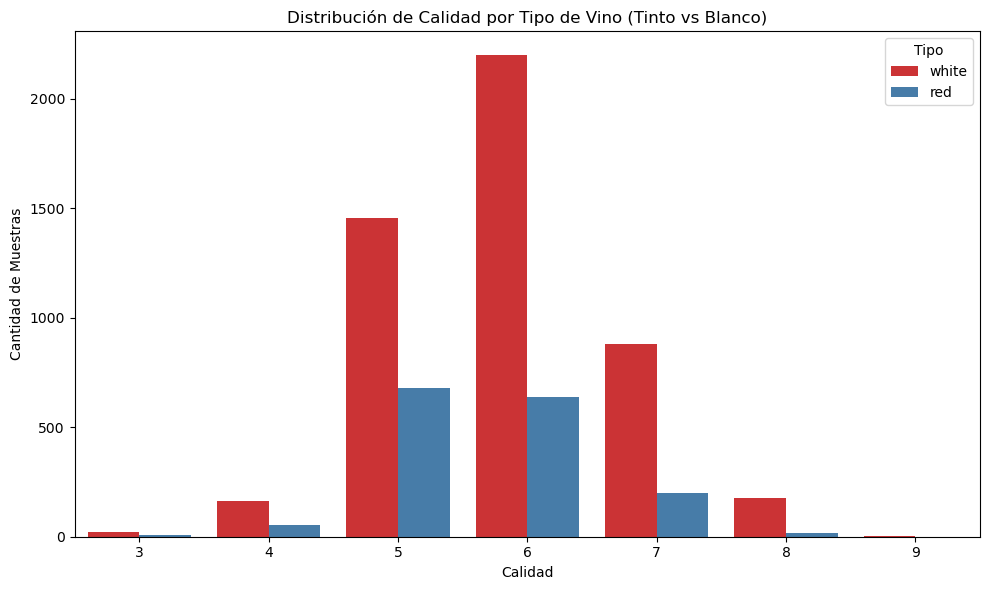

In [5]:
# Distribución de calidad por tipo de vino
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', hue='Type', data=df, palette='Set1')
plt.title('Distribución de Calidad por Tipo de Vino (Tinto vs Blanco)')
plt.xlabel('Calidad')
plt.ylabel('Cantidad de Muestras')
plt.legend(title='Tipo')
plt.tight_layout()
plt.savefig('grafica_calidad_por_tipo.png', dpi=150)
plt.show()

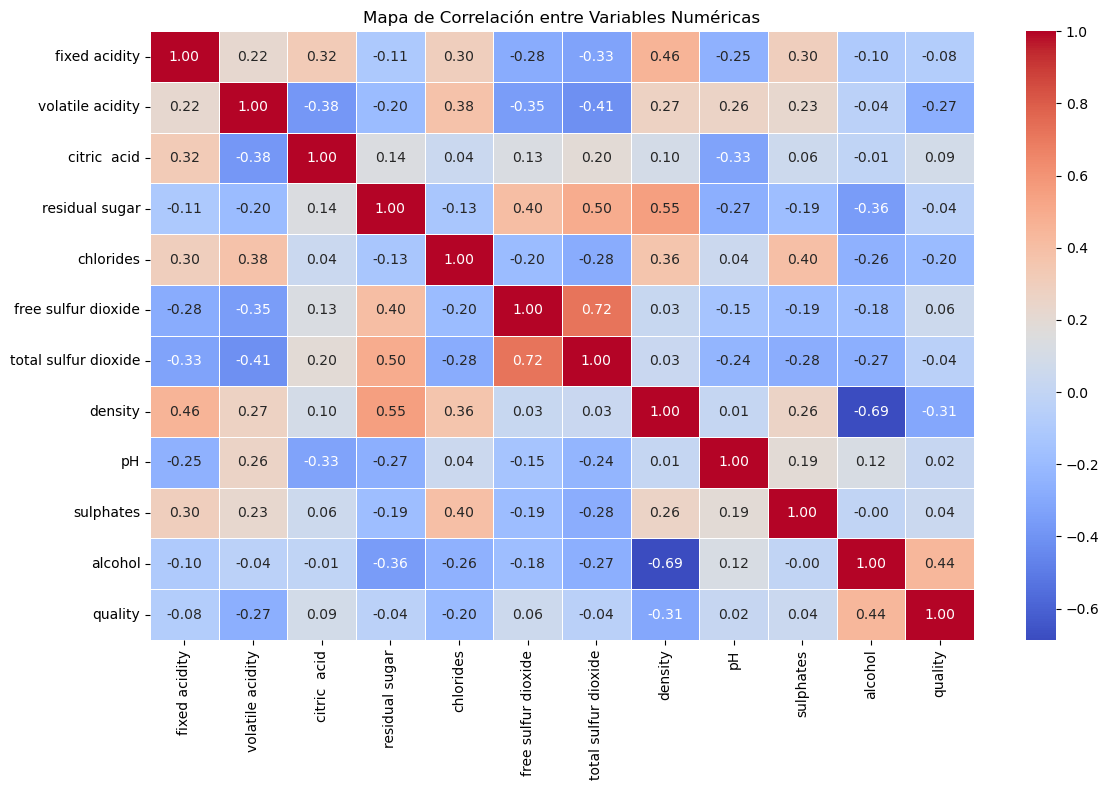

In [6]:
# Mapa de correlación entre variables numéricas
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Correlación entre Variables Numéricas')
plt.tight_layout()
plt.savefig('grafica_correlacion.png', dpi=150)
plt.show()

In [ ]:
# Distribución de las variables numéricas más relevantes
# Busca la columna de citric acid sin importar variaciones en el nombre
citric_col = [c for c in df.columns if 'citric' in c.lower()][0]
features_to_plot = ['alcohol', 'pH', 'sulphates', 'volatile acidity', citric_col]

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 4))
for ax, col in zip(axes, features_to_plot):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribución de Variables Clave', fontsize=14)
plt.tight_layout()
plt.savefig('grafica_distribucion_variables.png', dpi=150)
plt.show()

---
## 4. Preprocesamiento de Datos

In [ ]:
# Usar una copia del dataframe original
data = df.copy()

# Separar características (X) y variable objetivo (y)
X = data.drop(['id', 'quality'], axis=1)
y = data['quality']

# Convertir variable categórica Type a numérica (1=red, 0=white)
X['Type'] = (X['Type'] == 'red').astype(int)

print('=== Variables independientes (X) ===')
print(X.head())
print()
print('=== Variable objetivo (y) ===')
print(y.head())

In [ ]:
# Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40
)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba:        {X_test.shape[0]} muestras')

In [ ]:
# Escalamiento de datos (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalamiento completado.')
print(f'Media de X_train_scaled ≈ {X_train_scaled.mean():.6f} (debe ser ~0)')
print(f'Desv. estándar          ≈ {X_train_scaled.std():.6f}  (debe ser ~1)')

---
## 5. Modelo de Red Neuronal (MLPRegressor)

In [ ]:
# Modelo base solicitado en el proyecto
nn_model = MLPRegressor(hidden_layer_sizes=(6, 6), max_iter=1000, random_state=42)
nn_model.fit(X_train_scaled, y_train)

nn_pred = nn_model.predict(X_test_scaled)

nn_mse = mean_squared_error(y_test, nn_pred)
nn_r2  = r2_score(y_test, nn_pred)

print('=== Resultados de la Red Neuronal (configuración base) ===')
print(f'Arquitectura:             hidden_layer_sizes=(6, 6)')
print(f'Error Cuadrático Medio (MSE): {nn_mse:.4f}')
print(f'R-cuadrado (R²):              {nn_r2:.4f}')

---
## 6. Ajuste de Hiperparámetros de la Red Neuronal

In [ ]:
# Exploración de distintas arquitecturas
configs = [
    {'hidden_layer_sizes': (6, 6),      'max_iter': 1000, 'random_state': 42},
    {'hidden_layer_sizes': (8,),         'max_iter': 1000, 'random_state': 42},
    {'hidden_layer_sizes': (16, 8),      'max_iter': 1500, 'random_state': 42},
    {'hidden_layer_sizes': (32, 16, 8),  'max_iter': 2000, 'random_state': 42},
    {'hidden_layer_sizes': (64, 32),     'max_iter': 2000, 'random_state': 0},
    {'hidden_layer_sizes': (100, 50, 25),'max_iter': 3000, 'random_state': 0},
]

resultados = []
for cfg in configs:
    m = MLPRegressor(**cfg)
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    mse  = mean_squared_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    resultados.append({
        'Arquitectura':   str(cfg['hidden_layer_sizes']),
        'max_iter':       cfg['max_iter'],
        'random_state':   cfg['random_state'],
        'MSE':            round(mse, 4),
        'R²':             round(r2, 4)
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

In [ ]:
# Seleccionar la mejor configuración (menor MSE)
mejor_idx  = df_resultados['MSE'].idxmin()
mejor_cfg  = configs[mejor_idx]

nn_best = MLPRegressor(**mejor_cfg)
nn_best.fit(X_train_scaled, y_train)
nn_best_pred = nn_best.predict(X_test_scaled)

nn_best_mse = mean_squared_error(y_test, nn_best_pred)
nn_best_r2  = r2_score(y_test, nn_best_pred)

print('=== Mejor configuración encontrada ===')
print(f'Arquitectura:  {mejor_cfg["hidden_layer_sizes"]}')
print(f'max_iter:      {mejor_cfg["max_iter"]}')
print(f'random_state:  {mejor_cfg["random_state"]}')
print(f'MSE:           {nn_best_mse:.4f}')
print(f'R²:            {nn_best_r2:.4f}')

---
## 7. Modelo de Regresión Lineal (comparativo)

In [ ]:
# Crear y entrenar el modelo de regresión lineal
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Hacer predicciones
lr_pred = lr_model.predict(X_test_scaled)

# Evaluar
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)

print('=== Resultados de la Regresión Lineal ===')
print(f'Error Cuadrático Medio (MSE): {lr_mse:.4f}')
print(f'R-cuadrado (R²):              {lr_r2:.4f}')

---
## 8. Comparación de Modelos

In [ ]:
# Tabla comparativa
comparacion = pd.DataFrame({
    'Modelo':  ['Red Neuronal (base)', 'Red Neuronal (optimizada)', 'Regresión Lineal'],
    'MSE':     [round(nn_mse, 4), round(nn_best_mse, 4), round(lr_mse, 4)],
    'R²':      [round(nn_r2,  4), round(nn_best_r2,  4), round(lr_r2,  4)]
})
print(comparacion.to_string(index=False))

In [ ]:
# Gráfica comparativa de predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [nn_best_pred, lr_pred],
    ['Red Neuronal (optimizada)', 'Regresión Lineal']
):
    ax.scatter(y_test, pred, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
    mn, mx = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', label='Predicción perfecta')
    ax.set_xlabel('Calidad Real')
    ax.set_ylabel('Calidad Predicha')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Predicción vs Valor Real', fontsize=14)
plt.tight_layout()
plt.savefig('grafica_comparacion_modelos.png', dpi=150)
plt.show()

In [ ]:
# Gráfica de barras MSE y R² por modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
modelos = ['Red Neuronal\n(base)', 'Red Neuronal\n(optimizada)', 'Regresión\nLineal']
mse_vals = [nn_mse, nn_best_mse, lr_mse]
r2_vals  = [nn_r2,  nn_best_r2,  lr_r2]

axes[0].bar(modelos, mse_vals, color=['#4c72b0','#55a868','#c44e52'])
axes[0].set_title('Error Cuadrático Medio (MSE)\n(menor es mejor)')
axes[0].set_ylabel('MSE')

axes[1].bar(modelos, r2_vals, color=['#4c72b0','#55a868','#c44e52'])
axes[1].set_title('R-cuadrado (R²)\n(mayor es mejor)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('grafica_metricas_comparacion.png', dpi=150)
plt.show()

---
## 9. Resumen Final de Resultados

In [ ]:
print('=' * 55)
print('       RESUMEN FINAL DE RESULTADOS')
print('=' * 55)
print(f'{'Modelo':<30} {'MSE':>8} {'R²':>10}')
print('-' * 55)
print(f'{'Red Neuronal (base)':<30} {nn_mse:>8.4f} {nn_r2:>10.4f}')
print(f'{'Red Neuronal (optimizada)':<30} {nn_best_mse:>8.4f} {nn_best_r2:>10.4f}')
print(f'{'Regresión Lineal':<30} {lr_mse:>8.4f} {lr_r2:>10.4f}')
print('=' * 55)

mejor_modelo = comparacion.loc[comparacion['MSE'].idxmin(), 'Modelo']
print(f'\nMejor modelo por MSE: {mejor_modelo}')